# 1.記述子の作成
データを学習データとテストデータに分けて、記述子計算・前処理を行います。記述子はRDKit, Mordred(2次元/3次元)、おまけでFingerprintを計算します（Fingerprintは計算だけで予測モデルは作りません）。

## ライブラリ読み込み

In [1]:
# ライブラリの読み込み
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import IPython
from IPython.display import display

from rdkit import rdBase, Chem
from rdkit.Chem import AllChem, Descriptors, Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.ML.Descriptors import MoleculeDescriptors

from mordred import Calculator, descriptors

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import json
import scipy

## データ読み込み

In [2]:
# データ読み込み、0列目(Material)をindexに
dataset = pd.read_csv('data/material_data.csv', index_col=0)

display(dataset.head())

,SMILES,Type,PL
Material,,,
BTD1,CC1(C)C2=CC(C3=C(N=S=N4)C4=C(C5=CC=C(C6=CC=CC=...,BTD,533.0
BTD2,CC1(C)C2=CC(C3=C(N=S=N4)C4=C(C5=CC=C(C6=CC=C(C...,BTD,540.0
BTD3,CC1(C)C2=C(C=CC(C3=CC(N4C(C=CC=C5)=C5C6=C4C=CC...,BTD,538.0
BTD4,CC1(C)C2=CC(C3=C(N=S=N4)C4=C(C5=CC=C(C6=CC=C(N...,BTD,584.0
BTD5,CC1(C)C2=CC(C3=C(N=S=N4)C4=C(C5=CC=C(C6=CC=C(C...,BTD,540.0


In [3]:
# 学習データとPLが空欄のテストデータに分ける
dataset_train = dataset[dataset['PL'].notnull()]
dataset_test = dataset[dataset['PL'].isnull()]

# 保存しておく
dataset_train.to_csv('data/dataset_train.csv', index=True)
dataset_test.to_csv('data/dataset_test.csv', index=True)

print("dataset_train:", dataset_train.shape)
print("dataset_test:", dataset_test.shape)

dataset_train: (251, 3)
dataset_test: (1007, 3)


## RDkit
まず学習データの記述子を計算・前処理し、その後、テストデータでもやる

### 学習データ

In [4]:
# smiles列を抽出
smiles_train = dataset_train['SMILES']

# 計算する記述子名の取得
descriptor_names = []

for descriptor_information in Descriptors.descList:
    descriptor_names.append(descriptor_information[0])

print('計算する記述子の数：', len(descriptor_names))

計算する記述子の数： 217


In [5]:
# 記述子計算器
descriptor_calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

# 空のリストに計算結果を格納していく
descriptors_rdkit_train = []

for index, smiles_i in enumerate(smiles_train):
    print(index + 1, '/', len(smiles_train))
    mol = Chem.MolFromSmiles(smiles_i)

    # 不正なSMILESの場合はNaNを格納
    if mol is None:
        descriptors_rdkit_train.append([np.nan] * len(descriptor_names))
        continue

    descriptors_rdkit_train.append(
        descriptor_calculator.CalcDescriptors(mol)
    )

# DataFrame化（indexは dataset_train に合わせる）
descriptor_rdkit_train = pd.DataFrame(
    descriptors_rdkit_train,
    index=dataset_train.index,
    columns=descriptor_names
)

display(descriptor_rdkit_train.head())

1 / 251
2 / 251
3 / 251
4 / 251
5 / 251
6 / 251
7 / 251
8 / 251
9 / 251
10 / 251
11 / 251
12 / 251
13 / 251
14 / 251
15 / 251
16 / 251
17 / 251
18 / 251
19 / 251
20 / 251
21 / 251
22 / 251
23 / 251
24 / 251
25 / 251
26 / 251
27 / 251
28 / 251
29 / 251
30 / 251
31 / 251
32 / 251
33 / 251
34 / 251
35 / 251
36 / 251
37 / 251
38 / 251
39 / 251
40 / 251
41 / 251
42 / 251
43 / 251
44 / 251
45 / 251
46 / 251
47 / 251
48 / 251
49 / 251
50 / 251
51 / 251
52 / 251
53 / 251
54 / 251
55 / 251
56 / 251
57 / 251
58 / 251
59 / 251
60 / 251
61 / 251
62 / 251
63 / 251
64 / 251
65 / 251
66 / 251
67 / 251
68 / 251
69 / 251
70 / 251
71 / 251
72 / 251
73 / 251
74 / 251
75 / 251
76 / 251
77 / 251
78 / 251
79 / 251
80 / 251
81 / 251
82 / 251
83 / 251
84 / 251
85 / 251
86 / 251
87 / 251
88 / 251
89 / 251
90 / 251
91 / 251
92 / 251
93 / 251
94 / 251
95 / 251
96 / 251
97 / 251
98 / 251
99 / 251
100 / 251
101 / 251
102 / 251
103 / 251
104 / 251
105 / 251
106 / 251
107 / 251
108 / 251
109 / 251
110 / 251
111 / 25

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
Material,,,,,,,,,,,,,,,,,,,,,
BTD1,4.814638,4.814638,0.031632,-0.031632,0.216906,16.205128,520.701,492.477,520.197320,188,...,0,0,0,0,0,0,0,0,0,0
BTD2,5.006910,5.006910,0.211411,-0.211411,0.159110,14.233766,1003.287,952.887,1002.375619,364,...,0,0,0,0,0,0,0,0,0,0
BTD3,5.006077,5.006077,0.214711,-0.214711,0.166391,13.922078,1003.287,952.887,1002.375619,364,...,0,0,0,0,0,0,0,0,0,0
BTD4,4.969197,4.969197,0.216216,-0.216216,0.152454,14.153846,855.123,808.755,854.344318,312,...,0,0,0,0,0,0,0,0,0,0
BTD5,5.020606,5.020606,0.232982,-0.232982,0.159110,14.233766,1003.287,952.887,1002.375619,364,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# ============================================================
# 前処理用の関数群（Mordred 記述子などでも共通利用）
# ============================================================

def _coerce_numeric_df(X: pd.DataFrame):
    """
    役割：
        DataFrame の全列を数値型に変換（coerce）し、
        それでも数値化できない列を削除する。

    Returns:
        X_num : 数値型に変換後の DataFrame
        dropped_non_numeric_cols : 数値化できず削除された列名のリスト
    """
    X2 = X.copy()

    # 数値型でない列を抽出
    non_numeric_cols = X2.select_dtypes(exclude="number").columns.tolist()

    # 数値変換を試みる（変換できないものは NaN）
    for col in non_numeric_cols:
        X2[col] = pd.to_numeric(X2[col], errors="coerce")

    # それでも数値型でない列を削除
    still_non_numeric = X2.select_dtypes(exclude="number").columns.tolist()
    if len(still_non_numeric) > 0:
        X2 = X2.drop(columns=still_non_numeric, errors="ignore")

    return X2, still_non_numeric


def fit_preprocess_rule(
    X_train: pd.DataFrame,
    missing_rate_threshold: float = 0.30,
) -> dict:
    """
    学習データ（train）のみを用いて前処理ルールを決定する関数。

    処理内容：
        1. 非数値列を数値に変換し、変換できない列を削除
        2. ±inf を NaN に置換
        3. 欠損率が threshold を超える列を削除
        4. 標準偏差が 0 の列を削除
        5. 平均値が NaN になる列を削除
        6. 欠損値補完用の平均値を計算
        7. 使用する特徴量列を確定

    Returns:
        rule : 前処理ルールをまとめた辞書
    """
    if not isinstance(X_train, pd.DataFrame):
        raise TypeError("X_train は pandas DataFrame である必要があります。")

    X = X_train.copy()

    # 1) 非数値列を数値に変換し、残った非数値列を削除
    X, dropped_non_numeric_cols = _coerce_numeric_df(X)

    # 2) inf を NaN に変換
    X = X.replace([np.inf, -np.inf], np.nan)

    # 3) 欠損率が閾値を超える列を削除（train 基準）
    missing_rate = X.isna().mean(axis=0)
    drop_cols_missing = missing_rate[missing_rate > missing_rate_threshold].index.tolist()
    X2 = X.drop(columns=drop_cols_missing, errors="ignore")

    # 4) 標準偏差が 0 の列を削除（train 基準）
    std = X2.std(axis=0, skipna=True)
    drop_cols_zero_std = std[std == 0].index.tolist()
    X3 = X2.drop(columns=drop_cols_zero_std, errors="ignore")

    # 5,6) 欠損値補完用の平均値を計算
    means = X3.mean(axis=0, skipna=True)
    drop_cols_mean_nan = means[means.isna()].index.tolist()
    if len(drop_cols_mean_nan) > 0:
        X3 = X3.drop(columns=drop_cols_mean_nan, errors="ignore")
        means = X3.mean(axis=0, skipna=True)

    feature_columns = X3.columns.tolist()

    rule = {
        "missing_rate_threshold": float(missing_rate_threshold),
        "dropped_non_numeric_cols": dropped_non_numeric_cols,
        "drop_cols_missing": drop_cols_missing,
        "drop_cols_zero_std": drop_cols_zero_std,
        "drop_cols_mean_nan": drop_cols_mean_nan,
        "impute_means": means.to_dict(),
        "feature_columns": feature_columns,
    }
    return rule


def transform_with_rule(
    X_any: pd.DataFrame,
    rule: dict,
) -> pd.DataFrame:
    """
    学習データで決定した前処理ルールを、
    任意のデータ（train / validation / test）に適用する関数。

    処理内容：
        1. 非数値列を数値に変換し、残った非数値列を削除
        2. ±inf を NaN に置換
        3. 学習時に削除すると決めた列を削除
        4. 学習時の特徴量列に揃える（不足列は NaN で追加）
        5. 学習データの平均値で欠損値補完
        6. 列順を学習データと一致させて返す
    """
    if not isinstance(X_any, pd.DataFrame):
        raise TypeError("X_any は pandas DataFrame である必要があります。")

    X = X_any.copy()

    # 1) 非数値列を数値に変換し、残った非数値列を削除
    X, still_non_numeric = _coerce_numeric_df(X)

    # 2) inf を NaN に変換
    X = X.replace([np.inf, -np.inf], np.nan)

    # 3) 学習時に削除すると決めた列を削除
    drop_cols = (
        rule.get("dropped_non_numeric_cols", [])
        + rule.get("drop_cols_missing", [])
        + rule.get("drop_cols_zero_std", [])
        + rule.get("drop_cols_mean_nan", [])
    )
    drop_cols = list(dict.fromkeys(drop_cols))  # 重複除去
    X = X.drop(columns=drop_cols, errors="ignore")

    # 4) 学習時の特徴量列に合わせる
    feature_columns = rule["feature_columns"]
    missing_cols = [c for c in feature_columns if c not in X.columns]
    if len(missing_cols) > 0:
        X[missing_cols] = np.nan

    X = X[feature_columns]

    # 5) 学習データの平均値で欠損補完
    means = pd.Series(rule["impute_means"]).reindex(feature_columns)
    X = X.fillna(means)

    return X

In [7]:
# 学習データにおける説明変数を元に前処理のルールを決定
rule_rdkit = fit_preprocess_rule(
    X_train=descriptor_rdkit_train,
    missing_rate_threshold=0.30,
)

print("=== rule_rdkit summary ===")
print("n_features (after fit):", len(rule_rdkit["feature_columns"]))
print("dropped non-numeric cols:", len(rule_rdkit["dropped_non_numeric_cols"]))
print("drop missing cols:", len(rule_rdkit["drop_cols_missing"]))
print("drop zero-std cols:", len(rule_rdkit["drop_cols_zero_std"]))
print("drop mean-NaN cols:", len(rule_rdkit["drop_cols_mean_nan"]))

=== rule_rdkit summary ===
n_features (after fit): 152
dropped non-numeric cols: 0
drop missing cols: 0
drop zero-std cols: 65
drop mean-NaN cols: 0


In [8]:
# 学習データをtransform
X_train_rdkit_processed = transform_with_rule(descriptor_rdkit_train, rule_rdkit)

print("X_train_rdkit_processed shape:", X_train_rdkit_processed.shape)
display(X_train_rdkit_processed.head())

X_train_rdkit_processed shape: (251, 152)


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_pyridine,fr_sulfide,fr_thiophene,fr_unbrch_alkane
Material,,,,,,,,,,,,,,,,,,,,,
BTD1,4.814638,4.814638,0.031632,-0.031632,0.216906,16.205128,520.701,492.477,520.197320,188,...,0,0,0,0,0,0,0,0,0,0
BTD2,5.006910,5.006910,0.211411,-0.211411,0.159110,14.233766,1003.287,952.887,1002.375619,364,...,0,0,0,4,0,0,0,0,0,0
BTD3,5.006077,5.006077,0.214711,-0.214711,0.166391,13.922078,1003.287,952.887,1002.375619,364,...,0,0,0,4,0,0,0,0,0,0
BTD4,4.969197,4.969197,0.216216,-0.216216,0.152454,14.153846,855.123,808.755,854.344318,312,...,0,0,0,4,0,0,0,0,0,0
BTD5,5.020606,5.020606,0.232982,-0.232982,0.159110,14.233766,1003.287,952.887,1002.375619,364,...,0,0,0,6,0,0,0,0,0,0


### テストデータ

In [ ]:
# smiles列を抽出（テスト）
smiles_test = dataset_test['SMILES']

print("テスト分子数:", len(smiles_test))

# descriptor_names は学習時に作ったものをそのまま使う
print("記述子数:", len(descriptor_names))

# 記述子計算器
descriptor_calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

descriptors_rdkit_test = []

for index, smiles_i in enumerate(smiles_test):
    print(index + 1, '/', len(smiles_test))
    mol = Chem.MolFromSmiles(smiles_i)

    # 不正なSMILESの場合はNaNを格納
    if mol is None:
        descriptors_rdkit_test.append([np.nan] * len(descriptor_names))
        continue

    descriptors_rdkit_test.append(
        descriptor_calculator.CalcDescriptors(mol)
    )

# DataFrame化（indexは dataset_test に合わせる）
descriptor_rdkit_test = pd.DataFrame(
    descriptors_rdkit_test,
    index=dataset_test.index,
    columns=descriptor_names
)

display(descriptor_rdkit_test.head())


テスト分子数: 1007
記述子数: 217
1 / 1007


2 / 1007
3 / 1007
4 / 1007
5 / 1007
6 / 1007
7 / 1007
8 / 1007
9 / 1007
10 / 1007
11 / 1007
12 / 1007
13 / 1007
14 / 1007
15 / 1007
16 / 1007
17 / 1007
18 / 1007
19 / 1007
20 / 1007
21 / 1007
22 / 1007
23 / 1007
24 / 1007
25 / 1007
26 / 1007
27 / 1007
28 / 1007
29 / 1007
30 / 1007
31 / 1007
32 / 1007
33 / 1007
34 / 1007
35 / 1007
36 / 1007
37 / 1007
38 / 1007
39 / 1007
40 / 1007
41 / 1007
42 / 1007
43 / 1007
44 / 1007
45 / 1007
46 / 1007
47 / 1007
48 / 1007
49 / 1007
50 / 1007
51 / 1007
52 / 1007
53 / 1007
54 / 1007
55 / 1007
56 / 1007
57 / 1007
58 / 1007
59 / 1007
60 / 1007
61 / 1007
62 / 1007
63 / 1007
64 / 1007
65 / 1007
66 / 1007
67 / 1007
68 / 1007
69 / 1007
70 / 1007
71 / 1007
72 / 1007
73 / 1007
74 / 1007
75 / 1007
76 / 1007
77 / 1007
78 / 1007
79 / 1007
80 / 1007
81 / 1007
82 / 1007
83 / 1007
84 / 1007
85 / 1007
86 / 1007
87 / 1007
88 / 1007
89 / 1007
90 / 1007
91 / 1007
92 / 1007
93 / 1007
94 / 1007
95 / 1007
96 / 1007
97 / 1007
98 / 1007
99 / 1007
100 / 1007
101 / 1007
102 / 

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
Material,,,,,,,,,,,,,,,,,,,,,
test1,4.989597,4.989597,0.899100,0.899100,0.152213,11.661972,923.157,880.821,922.313018,332,...,0,0,0,0,0,0,0,0,0,0
test2,4.888286,4.888286,0.952110,0.952110,0.153489,11.929825,791.083,752.779,790.225860,276,...,0,0,0,0,0,0,0,2,0,0
test3,4.957730,4.957730,0.912759,0.912759,0.153597,11.448276,785.054,744.734,784.269439,280,...,0,0,0,0,0,0,0,2,0,0
test4,4.882803,4.882803,0.953277,0.953277,0.136992,11.753846,887.171,848.867,886.225860,308,...,0,0,0,0,0,0,0,2,0,0
test5,4.952248,4.952248,0.913925,0.913925,0.136983,11.333333,881.142,840.822,880.269439,312,...,0,0,0,0,0,0,0,2,0,0


In [10]:
# 学習基準ルールを使ってテストデータをtransform
X_test_rdkit_processed = transform_with_rule(
    descriptor_rdkit_test,
    rule_rdkit
)

print("X_test_rdkit_processed shape:", X_test_rdkit_processed.shape)
display(X_test_rdkit_processed.head())

X_test_rdkit_processed shape: (1007, 152)


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_pyridine,fr_sulfide,fr_thiophene,fr_unbrch_alkane
Material,,,,,,,,,,,,,,,,,,,,,
test1,4.989597,4.989597,0.899100,0.899100,0.152213,11.661972,923.157,880.821,922.313018,332,...,0,0,0,0,0,0,0,0,0,0
test2,4.888286,4.888286,0.952110,0.952110,0.153489,11.929825,791.083,752.779,790.225860,276,...,0,0,0,0,0,0,0,0,2,0
test3,4.957730,4.957730,0.912759,0.912759,0.153597,11.448276,785.054,744.734,784.269439,280,...,0,0,0,0,0,0,0,0,2,0
test4,4.882803,4.882803,0.953277,0.953277,0.136992,11.753846,887.171,848.867,886.225860,308,...,0,0,0,4,0,0,0,0,2,0
test5,4.952248,4.952248,0.913925,0.913925,0.136983,11.333333,881.142,840.822,880.269439,312,...,0,0,0,4,0,0,0,0,2,0


In [11]:
# 列が学習データと一致しているか確認
print("train/test column match?:", (X_train_rdkit_processed.columns == X_test_rdkit_processed.columns).all())

train/test column match?: True


### 保存

In [12]:
# 保存先ディレクトリ
os.makedirs("outputs/descriptors/rdkit", exist_ok=True)

# 前処理ルールを保存
with open("outputs/descriptors/rdkit/preprocess_rule.json", "w") as f:
    json.dump(rule_rdkit, f, indent=2)

# 説明変数の保存
X_train_rdkit_processed.to_csv(
    "outputs/descriptors/rdkit/X_train_rdkit_processed.csv",
    index=True
)

X_test_rdkit_processed.to_csv(
    "outputs/descriptors/rdkit/X_test_rdkit_processed.csv",
    index=True
)

print("saved:")
print(" - outputs/descriptors/rdkit/preprocess_rule.json")
print(" - outputs/descriptors/rdkit/X_train_rdkit_processed.csv")
print(" - outputs/descriptors/rdkit/X_test_rdkit_processed.csv")

saved:
 - outputs/descriptors/rdkit/preprocess_rule.json
 - outputs/descriptors/rdkit/X_train_rdkit_processed.csv
 - outputs/descriptors/rdkit/X_test_rdkit_processed.csv


## FP

### 学習データ

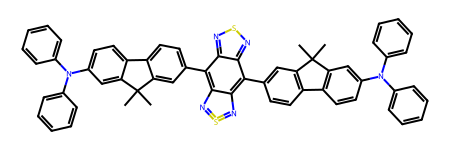

In [13]:
# molの作成
mols_train = [Chem.MolFromSmiles(smiles_i) for smiles_i in smiles_train]

# 正しく描写できる？
mols_train[-1]

In [14]:
# 3次元構造も見ておこう
smiles_train = [Chem.MolToSmiles(mol) for mol in mols_train]

# それぞれの方法で3次元構造を生成

def DG(mols):
    """
    ディスタンス・ジオメトリー（DG）法, 2018.03までのデフォルト方法
    """
    DG_uff = []
    mhs = [Chem.AddHs(mol) for mol in mols]
    for mol in mhs:
        AllChem.EmbedMolecule(mol,
                              useBasicKnowledge=False,
                              useExpTorsionAnglePrefs=False)
        if AllChem.UFFHasAllMoleculeParams(mol):
            AllChem.UFFOptimizeMolecule(mol)
            DG_uff.append(mol)
    return DG_uff

def ETDG(mols):
    """
    useExpTorsionAnglePrefs=True
    """
    ETDG_mols = []
    mhs = [Chem.AddHs(mol) for mol in mols]
    for mol in mhs:
        AllChem.EmbedMolecule(mol, AllChem.ETDG())
        ETDG_mols.append(mol)
    return ETDG_mols

def ETKDG(mols, version=1):
    """
    useBasicKnowledge=True
    useExpTorsionAnglePrefs=True
    2018.09以降のデフォルト方法
    """
    ETKDG_mols = []
    mhs = [Chem.AddHs(mol) for mol in mols]
    for mol in mhs:
        if version == 1:
            p = AllChem.ETKDG()
        elif version == 2:
            p = AllChem.ETKDGv2()
        elif version == 3:
            p = AllChem.ETKDGv3()
        else:
            print('invalid input')
        AllChem.EmbedMolecule(mol, p)
        ETKDG_mols.append(mol)
    return ETKDG_mols

In [15]:
# 3D構造生成
ETKDGv1_m = ETKDG(mols_train[0:5])

# 描写
IPythonConsole.drawMol3D(ETKDGv1_m[0])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [16]:
# Morgan fingerprint の計算

# fingerprint を格納する list
fingerprints_train = []

# Morgan fingerprint generator（radius=2, 2048 bit）
generator = GetMorganGenerator(radius=2, fpSize=2048)

print("学習分子数:", len(mols_train))

for i, mol in enumerate(mols_train):
    print(i + 1, "/", len(mols_train))

    # mol が None の場合
    if mol is None:
        fingerprints_train.append([0] * 2048)
        continue

    try:
        fingerprint = generator.GetFingerprint(mol)
        fingerprints_train.append(list(fingerprint))
    except Exception as e:
        print("fingerprint error at index:", i, e)
        fingerprints_train.append([0] * 2048)

# numpy array
fingerprints_train_np = np.array(fingerprints_train)

# DataFrame（index は dataset_train に合わせる）
X_train_fp = pd.DataFrame(
    fingerprints_train_np,
    index=dataset_train.index,
    columns=[f"FP_{i}" for i in range(2048)]
)

print("X_train_fp shape:", X_train_fp.shape)
display(X_train_fp.head())

学習分子数: 251
1 / 251
2 / 251
3 / 251
4 / 251
5 / 251
6 / 251
7 / 251
8 / 251
9 / 251
10 / 251
11 / 251
12 / 251
13 / 251
14 / 251
15 / 251
16 / 251
17 / 251
18 / 251
19 / 251
20 / 251
21 / 251
22 / 251
23 / 251
24 / 251
25 / 251
26 / 251
27 / 251
28 / 251
29 / 251
30 / 251
31 / 251
32 / 251
33 / 251
34 / 251
35 / 251
36 / 251
37 / 251
38 / 251
39 / 251
40 / 251
41 / 251
42 / 251
43 / 251
44 / 251
45 / 251
46 / 251
47 / 251
48 / 251
49 / 251
50 / 251
51 / 251
52 / 251
53 / 251
54 / 251
55 / 251
56 / 251
57 / 251
58 / 251
59 / 251
60 / 251
61 / 251
62 / 251
63 / 251
64 / 251
65 / 251
66 / 251
67 / 251
68 / 251
69 / 251
70 / 251
71 / 251
72 / 251
73 / 251
74 / 251
75 / 251
76 / 251
77 / 251
78 / 251
79 / 251
80 / 251
81 / 251
82 / 251
83 / 251
84 / 251
85 / 251
86 / 251
87 / 251
88 / 251
89 / 251
90 / 251
91 / 251
92 / 251
93 / 251
94 / 251
95 / 251
96 / 251
97 / 251
98 / 251
99 / 251
100 / 251
101 / 251
102 / 251
103 / 251
104 / 251
105 / 251
106 / 251
107 / 251
108 / 251
109 / 251
110 / 2

,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_2038,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047
Material,,,,,,,,,,,,,,,,,,,,,
BTD1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BTD2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BTD3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BTD4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BTD5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### テストデータ

In [17]:
# RDKit Mol を作成
mols_test = []
for i, smi in enumerate(smiles_test):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print("Mol parse failed at index:", i)
    mols_test.append(mol)

# fingerprint を格納する list
fingerprints_test = []

# ※ generator は学習データ計算時に作ったものをそのまま使う
# generator = GetMorganGenerator(radius=2, fpSize=2048) ← 再定義しない

for i, mol in enumerate(mols_test):
    print(i + 1, "/", len(mols_test))

    # mol が None の場合
    if mol is None:
        fingerprints_test.append([0] * 2048)
        continue

    try:
        fingerprint = generator.GetFingerprint(mol)
        fingerprints_test.append(list(fingerprint))
    except Exception as e:
        print("fingerprint error at index:", i, e)
        fingerprints_test.append([0] * 2048)

# numpy array
fingerprints_test_np = np.array(fingerprints_test)

# DataFrame 化（index は dataset_test に合わせる）
X_test_fp = pd.DataFrame(
    fingerprints_test_np,
    index=dataset_test.index,
    columns=[f"FP_{i}" for i in range(2048)]
)

print("X_test_fp shape:", X_test_fp.shape)
display(X_test_fp.head())

1 / 1007
2 / 1007
3 / 1007
4 / 1007
5 / 1007
6 / 1007
7 / 1007
8 / 1007
9 / 1007
10 / 1007
11 / 1007
12 / 1007
13 / 1007
14 / 1007
15 / 1007
16 / 1007
17 / 1007
18 / 1007
19 / 1007
20 / 1007
21 / 1007
22 / 1007
23 / 1007
24 / 1007
25 / 1007
26 / 1007
27 / 1007
28 / 1007
29 / 1007
30 / 1007
31 / 1007
32 / 1007
33 / 1007
34 / 1007
35 / 1007
36 / 1007
37 / 1007
38 / 1007
39 / 1007
40 / 1007
41 / 1007
42 / 1007
43 / 1007
44 / 1007
45 / 1007
46 / 1007
47 / 1007
48 / 1007
49 / 1007
50 / 1007
51 / 1007
52 / 1007
53 / 1007
54 / 1007
55 / 1007
56 / 1007
57 / 1007
58 / 1007
59 / 1007
60 / 1007
61 / 1007
62 / 1007
63 / 1007
64 / 1007
65 / 1007
66 / 1007
67 / 1007
68 / 1007
69 / 1007
70 / 1007
71 / 1007
72 / 1007
73 / 1007
74 / 1007
75 / 1007
76 / 1007
77 / 1007
78 / 1007
79 / 1007
80 / 1007
81 / 1007
82 / 1007
83 / 1007
84 / 1007
85 / 1007
86 / 1007
87 / 1007
88 / 1007
89 / 1007
90 / 1007
91 / 1007
92 / 1007
93 / 1007
94 / 1007
95 / 1007
96 / 1007
97 / 1007
98 / 1007
99 / 1007
100 / 1007
101 / 10

,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_2038,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047
Material,,,,,,,,,,,,,,,,,,,,,
test1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
test2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
test3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
test4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
test5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
# 列が学習データと一致しているか確認
print(
    "train/test column match?:",
    (X_train_fp.columns == X_test_fp.columns).all()
)

train/test column match?: True


### 保存

In [19]:
# 保存先ディレクトリ
os.makedirs("outputs/descriptors/fp", exist_ok=True)

# 最低限のメタ情報
fp_meta = {
    "type": "Morgan",
    "radius": 2,
    "fpSize": 2048,
    "columns_prefix": "FP_",
}

with open("outputs/descriptors/fp/fp_meta.json", "w") as f:
    json.dump(fp_meta, f, indent=2)

# 学習データ fingerprint
X_train_fp.to_csv(
    "outputs/descriptors/fp/X_train_fp.csv",
    index=True
)

# テストデータ fingerprint
X_test_fp.to_csv(
    "outputs/descriptors/fp/X_test_fp.csv",
    index=True
)

print("saved:")
print(" - outputs/descriptors/fp/fp_meta.json")
print(" - outputs/descriptors/fp/X_train_fp.csv")
print(" - outputs/descriptors/fp/X_test_fp.csv")

saved:
 - outputs/descriptors/fp/fp_meta.json
 - outputs/descriptors/fp/X_train_fp.csv
 - outputs/descriptors/fp/X_test_fp.csv


## Mordred

### 学習データ

In [20]:
# mol file作成
smiles_train = dataset_train["SMILES"]

mols_train = []
molhs_train = []

for smiles_i in smiles_train:
    # 通常のmol file
    mol = Chem.MolFromSmiles(smiles_i)
    mols_train.append(mol)

    # 3次元構造の入ったmol file
    molh = Chem.AddHs(mol)
    AllChem.EmbedMolecule(molh, AllChem.ETKDG())
    molhs_train.append(molh)

In [21]:
# 2次元記述子の計算
calc_2d = Calculator(descriptors, ignore_3D=True)
df_mordred_2d_train = calc_2d.pandas(mols_train)
# index を dataset_train に揃える
df_mordred_2d_train.index = dataset_train.index

print(f"計算直後の2D記述子 shape: {df_mordred_2d_train.shape}")
display(df_mordred_2d_train.head())

# 3次元記述子の計算
calc_3d = Calculator(descriptors, ignore_3D=False)
df_mordred_3d_train = calc_3d.pandas(molhs_train)
# index を dataset_train に揃える
df_mordred_3d_train.index = dataset_train.index

print(f"計算直後の3D記述子 shape: {df_mordred_3d_train.shape}")
display(df_mordred_3d_train.head())

  7%|▋         | 17/251 [00:12<02:44,  1.42it/s]

/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/

100%|██████████| 251/251 [01:47<00:00,  2.33it/s]


計算直後の2D記述子 shape: (251, 1613)


,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
Material,,,,,,,,,,,,,,,,,,,,,
BTD1,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,52.858928,2.605019,5.075721,52.858928,1.355357,4.657297,...,11.063085,95.162927,520.197320,7.764139,4998,81,238.0,303.0,10.430556,7.972222
BTD2,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,106.389455,2.619063,5.089934,106.389455,1.381681,5.337090,...,11.699944,138.030334,1002.375619,7.892721,36855,161,470.0,597.0,17.708333,15.861111
BTD3,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,106.360771,2.616201,5.087066,106.360771,1.381309,5.337090,...,11.699281,138.029670,1002.375619,7.892721,36739,161,470.0,597.0,17.708333,15.861111
BTD4,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,88.539924,2.617273,5.088287,88.539924,1.362153,5.150273,...,11.443500,123.348096,854.344318,7.696796,21841,129,382.0,477.0,15.819444,13.638889
BTD5,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,106.409272,2.620668,5.091786,106.409272,1.381939,5.337193,...,11.713783,138.055708,1002.375619,7.892721,35231,163,470.0,599.0,17.708333,15.916667


...

  8%|▊         | 19/251 [00:15<00:46,  5.03it/s]

/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 251/251 [02:01<00:00,  2.06it/s]


計算直後の3D記述子 shape: (251, 1826)


,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
Material,,,,,,,,,,,,,,,,,,,,,
BTD1,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,52.858928,2.605019,5.075721,52.858928,1.355357,4.657297,...,11.063085,95.162927,520.197320,7.764139,4998,81,238.0,303.0,10.430556,7.972222
BTD2,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,106.389455,2.619063,5.089934,106.389455,1.381681,5.337090,...,11.699944,138.030334,1002.375619,7.892721,36855,161,470.0,597.0,17.708333,15.861111
BTD3,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,106.360771,2.616201,5.087066,106.360771,1.381309,5.337090,...,11.699281,138.029670,1002.375619,7.892721,36739,161,470.0,597.0,17.708333,15.861111
BTD4,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,88.539924,2.617273,5.088287,88.539924,1.362153,5.150273,...,11.443500,123.348096,854.344318,7.696796,21841,129,382.0,477.0,15.819444,13.638889
BTD5,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,106.409272,2.620668,5.091786,106.409272,1.381939,5.337193,...,11.713783,138.055708,1002.375619,7.892721,35231,163,470.0,599.0,17.708333,15.916667


In [22]:
# 2D記述子の前処理
rule_mordred_2d = fit_preprocess_rule(
    X_train=df_mordred_2d_train,
    missing_rate_threshold=0.30,
)

X_train_mordred_2d_processed = transform_with_rule(
    X_any=df_mordred_2d_train,
    rule=rule_mordred_2d,
)

print("=== mordred 2D summary ===")
print("n_features:", len(rule_mordred_2d["feature_columns"]))
print("drop missing:", len(rule_mordred_2d["drop_cols_missing"]))
print("drop zero-std:", len(rule_mordred_2d["drop_cols_zero_std"]))
print("drop mean-NaN:", len(rule_mordred_2d["drop_cols_mean_nan"]))
print("dropped non-numeric:", len(rule_mordred_2d["dropped_non_numeric_cols"]))
print("processed shape:", X_train_mordred_2d_processed.shape)
print("any NaN left?:", X_train_mordred_2d_processed.isna().any().any())

=== mordred 2D summary ===
n_features: 1225
drop missing: 185
drop zero-std: 201
drop mean-NaN: 0
dropped non-numeric: 2
processed shape: (251, 1225)
any NaN left?: False


In [23]:
# 3D記述子の前処理
rule_mordred_3d = fit_preprocess_rule(
    X_train=df_mordred_3d_train,
    missing_rate_threshold=0.30,
)

X_train_mordred_3d_processed = transform_with_rule(
    X_any=df_mordred_3d_train,
    rule=rule_mordred_3d,
)

print("=== mordred 3D summary ===")
print("n_features:", len(rule_mordred_3d["feature_columns"]))
print("drop missing:", len(rule_mordred_3d["drop_cols_missing"]))
print("drop zero-std:", len(rule_mordred_3d["drop_cols_zero_std"]))
print("drop mean-NaN:", len(rule_mordred_3d["drop_cols_mean_nan"]))
print("dropped non-numeric:", len(rule_mordred_3d["dropped_non_numeric_cols"]))
print("processed shape:", X_train_mordred_3d_processed.shape)
print("any NaN left?:", X_train_mordred_3d_processed.isna().any().any())

=== mordred 3D summary ===
n_features: 1278
drop missing: 345
drop zero-std: 201
drop mean-NaN: 0
dropped non-numeric: 2
processed shape: (251, 1278)
any NaN left?: False


### テストデータ

In [24]:
# mol file作成（テストデータ）
smiles_test = dataset_test["SMILES"]

mols_test = []
molhs_test = []

for smiles_i in smiles_test:
    # 通常のmol
    mol = Chem.MolFromSmiles(smiles_i)
    mols_test.append(mol)

    # 3次元構造入り mol
    molh = Chem.AddHs(mol)
    AllChem.EmbedMolecule(molh, AllChem.ETKDG())
    molhs_test.append(molh)

In [25]:
# 1) Mordred 2D
calc_2d = Calculator(descriptors, ignore_3D=True)
df_mordred_2d_test = calc_2d.pandas(mols_test)

# index を dataset_test に揃える
df_mordred_2d_test.index = dataset_test.index

print("raw Mordred 2D (test) shape:", df_mordred_2d_test.shape)
display(df_mordred_2d_test.head())

# 2) Mordred 3D
calc_3d = Calculator(descriptors, ignore_3D=False)
df_mordred_3d_test = calc_3d.pandas(molhs_test)

# index を dataset_test に揃える
df_mordred_3d_test.index = dataset_test.index

print("raw Mordred 3D (test) shape:", df_mordred_3d_test.shape)
display(df_mordred_3d_test.head())

  0%|          | 4/1007 [00:06<1:54:45,  6.87s/it]

/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  1%|▏         | 14/1007 [00:07<05:14,  3.15it/s] 

/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  2%|▏         | 18/1007 [00:07<04:12,  3.91it/s]

...

 10%|▉         | 96/1007 [00:33<02:56,  5.16it/s]

/opt/conda/envs/mol-regression-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 1007/1007 [04:16<00:00,  3.93it/s]


raw Mordred 3D (test) shape: (1007, 1826)


,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
Material,,,,,,,,,,,,,,,,,,,,,
test1,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,99.284518,2.588874,5.055608,99.284518,1.398373,5.240185,...,11.444957,129.417222,922.313018,8.162062,26962,135,414.0,513.0,14.138889,15.083333
test2,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,76.857944,2.540886,4.968244,76.857944,1.348385,5.008959,...,11.138567,113.633060,790.225860,8.318167,15673,101,326.0,397.0,14.194444,12.027778
test3,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,78.378203,2.534140,4.993985,78.378203,1.351348,5.023509,...,11.156750,113.615865,784.269439,8.002749,16213,104,330.0,401.0,14.444444,12.277778
test4,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,89.807709,2.537202,4.958616,89.807709,1.381657,5.141958,...,11.248869,122.237982,886.225860,8.604135,24929,115,370.0,451.0,13.194444,13.916667
test5,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,91.324885,2.529792,4.989490,91.324885,1.383710,5.154707,...,11.265169,122.212572,880.269439,8.304429,25651,118,374.0,455.0,13.444444,14.166667


In [26]:
# 2D記述子の前処理（テストデータ）
X_test_mordred_2d_processed = transform_with_rule(
    X_any=df_mordred_2d_test,
    rule=rule_mordred_2d,
)

print("X_test_mordred_2d_processed shape:", X_test_mordred_2d_processed.shape)
print("any NaN left?:", X_test_mordred_2d_processed.isna().any().any())
print("any inf left?:", np.isinf(X_test_mordred_2d_processed.to_numpy()).any())

# 列一致チェック
print(
    "2D columns match train?:",
    (X_train_mordred_2d_processed.columns == X_test_mordred_2d_processed.columns).all())

X_test_mordred_2d_processed shape: (1007, 1225)
any NaN left?: False
any inf left?: False
2D columns match train?: True


In [27]:
# 3D記述子の前処理（テストデータ）
X_test_mordred_3d_processed = transform_with_rule(
    X_any=df_mordred_3d_test,
    rule=rule_mordred_3d,
)

print("X_test_mordred_3d_processed shape:", X_test_mordred_3d_processed.shape)
print("any NaN left?:", X_test_mordred_3d_processed.isna().any().any())
print("any inf left?:", np.isinf(X_test_mordred_3d_processed.to_numpy()).any())

# 列一致チェック
print(
    "3D columns match train?:",
    (X_train_mordred_3d_processed.columns == X_test_mordred_3d_processed.columns).all()
)

X_test_mordred_3d_processed shape: (1007, 1278)
any NaN left?: False
any inf left?: False
3D columns match train?: True


### 保存

In [28]:
# 2D
os.makedirs("outputs/descriptors/mordred_2d", exist_ok=True)

# 説明変数の保存
X_train_mordred_2d_processed.to_csv(
    "outputs/descriptors/mordred_2d/X_train_mordred_2d_processed.csv",
    index=True
)

X_test_mordred_2d_processed.to_csv(
    "outputs/descriptors/mordred_2d/X_test_mordred_2d_processed.csv",
    index=True
)

# ruleの保存
with open("outputs/descriptors/mordred_2d/preprocess_rule.json", "w") as f:
    json.dump(rule_mordred_2d, f, indent=2)

print("saved mordred_2d:")
print(" - outputs/descriptors/mordred_2d/X_train_mordred_2d_processed.csv")
print(" - outputs/descriptors/mordred_2d/X_test_mordred_2d_processed.csv")
print(" - outputs/descriptors/mordred_2d/preprocess_rule.json")


# 3D
os.makedirs("outputs/descriptors/mordred_3d", exist_ok=True)

# 説明変数の保存
X_train_mordred_3d_processed.to_csv(
    "outputs/descriptors/mordred_3d/X_train_mordred_3d_processed.csv",
    index=True
)

X_test_mordred_3d_processed.to_csv(
    "outputs/descriptors/mordred_3d/X_test_mordred_3d_processed.csv",
    index=True
)

# ruleの保存
with open("outputs/descriptors/mordred_3d/preprocess_rule.json", "w") as f:
    json.dump(rule_mordred_3d, f, indent=2)

print("saved mordred_3d:")
print(" - outputs/descriptors/mordred_3d/X_train_mordred_3d_processed.csv")
print(" - outputs/descriptors/mordred_3d/X_test_mordred_3d_processed.csv")
print(" - outputs/descriptors/mordred_3d/preprocess_rule.json")

saved mordred_2d:
 - outputs/descriptors/mordred_2d/X_train_mordred_2d_processed.csv
 - outputs/descriptors/mordred_2d/X_test_mordred_2d_processed.csv
 - outputs/descriptors/mordred_2d/preprocess_rule.json
saved mordred_3d:
 - outputs/descriptors/mordred_3d/X_train_mordred_3d_processed.csv
 - outputs/descriptors/mordred_3d/X_test_mordred_3d_processed.csv
 - outputs/descriptors/mordred_3d/preprocess_rule.json
